# TP2 : MCMC (Partie 1)

## G3 SDI - Estimation Avancée

Dans ce TP, on s'intéresse aux méthodes d'échantillonnage dites "MCMC" (Monte Carlo par Chaînes de Markov). Le premier exercice consiste à implémenter un Metropolis-Hastings et de regarder l'influence de quelques paramètres. Dans un deuxième exercice, on cherchera à implémenter un échantillonneur de Gibbs dans un modèle de régression linéaire bayésienne (disponible dans un deuxième notebook).

### Instructions

1. Renommez votre notebook sous la forme `tp2a_Nom1_Nom2.ipynb`. 

2. Votre code, ainsi que toute sortie du code, doivent être commentés !

3. Déposez votre notebook sur Moodle dans la section prévue à cet effet avant la date limite.

**Compte rendu — Ugo Roccamatisi.**


In [2]:
# Usual libraries
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as ss

### Exercice - Régression logistique bayésienne

Soit le modèle de régression logistique 1D suivant :
\begin{align}
\beta & \sim \mathcal{N}(0,4) \\
y | x_i, \beta & \sim \text{Bernoulli} \left( \frac{1}{1+\exp(-\beta x)} \right)
\end{align}

(I.e., on suppose que l'intercept vaut 0 pour simplifier).

Le posterior $p(\beta|\mathcal{D})$ est intractable, on va donc chercher à en tirer des échantillons par un algorithme Metropolis-Hastings (MH). On prendra comme loi instrumentale une loi normale centrée en l'état courant et de variance $\sigma^2$.


In [4]:
# Generate fake data from the model

np.random.seed(2024)

b = -2.5
N = 50
x = np.random.randn(N)
p = 1/(1+np.exp(-b*x))
y = np.random.rand(N) < p

**Q1.** Écrire une fonction implémentant l'algorithme MH proposé pour tirer des échantillons de $p(\beta|\mathcal{D})$, qui prend comme arguments :
* La taille de la chaine N ;
* L'état initial de la chaîne $\beta^{(0)}$ ;
* L'écart-type $\sigma$ de la *proposal* gaussienne ;
* Une graine aléatoire.

On utilisera les fonctions implémentées dans `scipy.stats` pour les pdfs !

In [6]:
from scipy.special import log_expit

def log_posterior(beta):
    # Prior N(0,4) : scale=2. log_expit rend le calcul stable aux extrêmes.
    return ss.norm.logpdf(beta,loc=0,scale=2)+np.sum(y*log_expit(beta*x)+(1-y)*log_expit(-beta*x))

def mh(N,beta0,sigma,seed):
    """Random-walk MH symétrique ; N états, dont l'état initial."""
    if N<2 or sigma<=0:raise ValueError('N>=2 et sigma>0 requis')
    rng=np.random.default_rng(seed);chain=np.empty(N);chain[0]=beta0
    old_log=log_posterior(beta0);accepted=0
    for i in range(1,N):
        candidate=chain[i-1]+rng.normal(scale=sigma)
        new_log=log_posterior(candidate)
        # q(candidate|current)=q(current|candidate), donc les q s'annulent.
        if np.log(rng.random())<min(0,new_log-old_log):
            chain[i]=candidate;old_log=new_log;accepted+=1
        else:chain[i]=chain[i-1]
    return chain,accepted/(N-1)

**Q2**. Prendre $N = 2000$ et $\beta^{(0)} = -1.5$. Afficher les *traceplots* (i.e. les échantillons en fonction de $n$) de la chaîne pour des valeurs différentes de $\sigma$ : $0.01, 0.5, 20$. Dans chaque cas, tracer un histogramme des échantillons obtenus. Commenter.

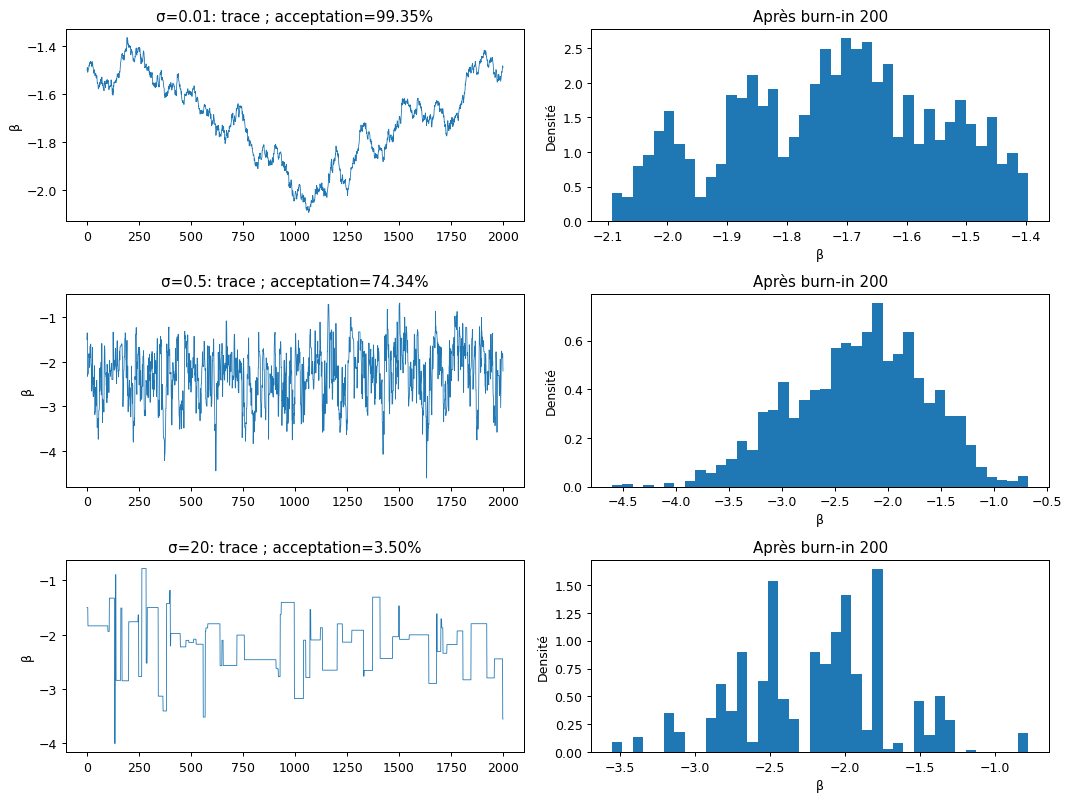

In [8]:
fig,axes=plt.subplots(3,2,figsize=(12,9))
for row,sigma in enumerate([.01,.5,20]):
    chain,accept=mh(2000,-1.5,sigma,seed=42)
    axes[row,0].plot(chain,lw=.65);axes[row,1].hist(chain[200:],bins=40,density=True)
    axes[row,0].set(ylabel='β',title=f'σ={sigma}: trace ; acceptation={accept:.2%}')
    axes[row,1].set(xlabel='β',ylabel='Densité',title='Après burn-in 200')
fig.tight_layout();plt.show()

**Réponse.** Une proposition trop étroite (σ=0,01) est presque toujours acceptée mais se déplace très lentement ; trop large (σ=20), elle est souvent rejetée et la chaîne répète ses états. σ=0,5 offre ici un meilleur compromis. Les histogrammes d’une chaîne mal mélangée dépendent fortement de sa trajectoire.

**Q3.** Prendre $N = 2000$ et $\sigma = 0.5$. Afficher les *traceplots* pour $\beta^{(0)}$ valant $-2$ et $20$. Dans chaque cas, tracer un histogramme des échantillons obtenus. Commenter.

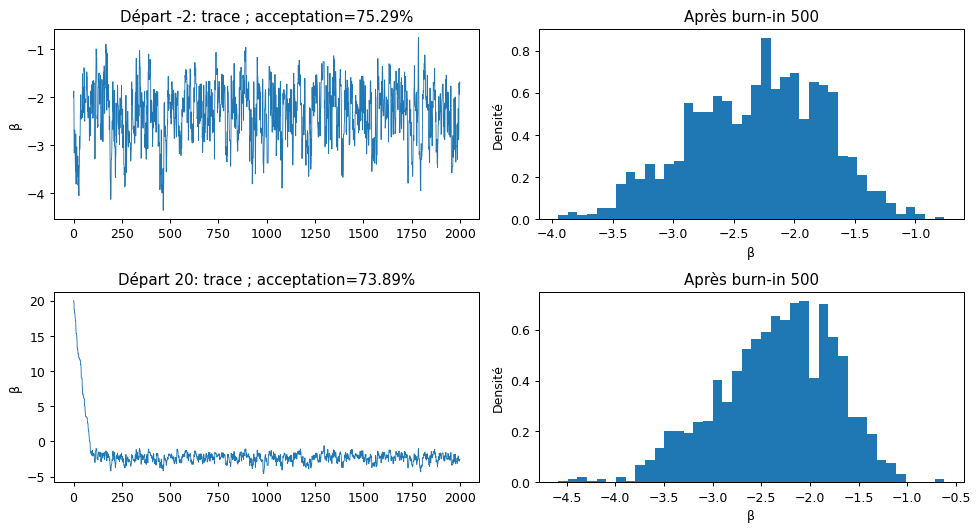

In [11]:
fig,axes=plt.subplots(2,2,figsize=(11,6))
for row,beta0 in enumerate([-2,20]):
    chain,accept=mh(2000,beta0,.5,seed=43)
    axes[row,0].plot(chain,lw=.7);axes[row,1].hist(chain[500:],bins=40,density=True)
    axes[row,0].set(ylabel='β',title=f'Départ {beta0}: trace ; acceptation={accept:.2%}')
    axes[row,1].set(xlabel='β',ylabel='Densité',title='Après burn-in 500')
fig.tight_layout();plt.show()

**Réponse.** Partir de β=20 place la chaîne loin de la zone de forte densité et impose une phase initiale de convergence ; le départ β=−2 est proche de la région plausible. Le burn-in supprime cette phase, sans garantir à lui seul l’indépendance des tirages.

**Q4.** À partir d'échantillons d'une chaîne avec des valeurs de $\beta^{(0)}$ et $\sigma$ bien choisies, donner le MMSE de $\beta$ ainsi que son intervalle de crédibilité à $95\%$.

Acceptation=73.95%; MMSE=-2.3089; intervalle crédible 95 %=[-3.5963,-1.2599]
Les tirages d’une chaîne sont corrélés : cet intervalle est descriptif, pas un IC fréquentiste.


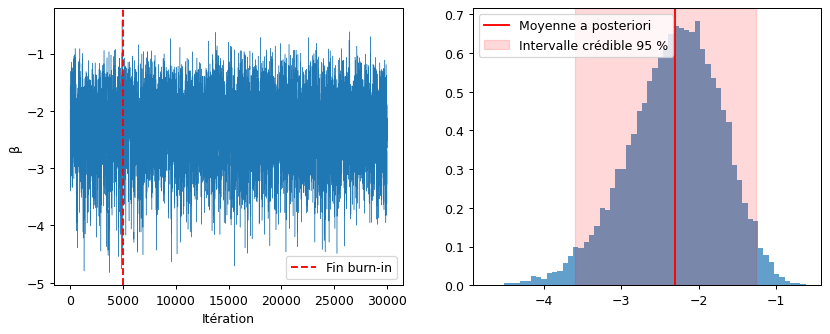

In [14]:
# Chaîne plus longue pour l'estimation ; l'initialisation est proche du cœur du posterior.
posterior_chain,accept=mh(30000,-2,.5,seed=44)
stationary=posterior_chain[5000:]
mmse=stationary.mean();ci=np.quantile(stationary,[.025,.975])
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(posterior_chain,lw=.35);axes[0].axvline(5000,c='r',ls='--',label='Fin burn-in');axes[0].legend();axes[0].set(xlabel='Itération',ylabel='β')
axes[1].hist(stationary,bins=60,density=True,alpha=.7);axes[1].axvline(mmse,c='r',label='Moyenne a posteriori');axes[1].axvspan(*ci,color='r',alpha=.15,label='Intervalle crédible 95 %');axes[1].legend();plt.show()
print(f'Acceptation={accept:.2%}; MMSE={mmse:.4f}; intervalle crédible 95 %=[{ci[0]:.4f},{ci[1]:.4f}]')
print('Les tirages d’une chaîne sont corrélés : cet intervalle est descriptif, pas un IC fréquentiste.')

**Réponse.** Le MMSE sous perte quadratique est la moyenne a posteriori empirique. Les quantiles 2,5 % et 97,5 % donnent l’intervalle de crédibilité central à 95 %. Son interprétation est bayésienne : probabilité a posteriori de 95 % pour le paramètre dans cet intervalle, sous le modèle.

**Résultat.** Après 5000 tirages écartés, la moyenne a posteriori est **−2,309** et l’intervalle crédible central à 95 % est **[−3,596 ; −1,260]**.
